<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 40px;
font-family: 'Segoe UI', sans-serif;
font-weight: 400;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b>
<span style="color: #ffffff;">Exercícios Aprendizado Profundo</span>
</div>

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">5) Implemente uma Rede Neural Recorrente (RNN), como por exemplo uma LSTM ou GRU,
para o problema de Análise de Sentimentos, utilizando a base de dados de resenhas de filmes
do IMDb (Internet Movie Database). Essa base contém 50 mil resenhas em inglês, sendo 25 mil
para treinamento e 25 mil para teste, cada uma acompanhada de uma avaliação binária que
indica se a resenha é negativa (0) ou positiva (1). A base está disponível em:
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews.
Descreva o processo de pré-processamento dos dados, a arquitetura da RNN implementada,
os parâmetros utilizados no treinamento e os principais resultados obtidos como acurácia e
curva de erro. Apresente também 5 (cinco) exemplos de resenhas do conjunto de teste,
acompanhados da predição do modelo e do rótulo verdadeiro</span>
</div>

In [1]:
import numpy as np
import pandas as pd

file  = "IMDB_data/IMDB Dataset.csv"
data = pd.read_csv(file)
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">PRÉ-PROCESSAMENTO</span>
</div>

In [2]:
import re
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
def rm_stop_words():
    return set(stopwords.words("english"))


def preprocess_text(text, max_words=200, remove_stopwords=True, stop_words=None):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)  # REMOVE HTML
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()  # REMOVE ESPAÇOS EXTRAS

    tokens = text.split()

    if remove_stopwords and stop_words is not None:
        tokens = [token for token in tokens if token not in stop_words]

    # Limita número de palavras por resenha
    tokens = tokens[:max_words]

    return " ".join(tokens)


In [4]:
max_word = 200  

stop_words = rm_stop_words()
data["review_clean"] = data["review"].apply(preprocess_text)
num_caracteres = len(data["review_clean"][0])
num_palavras = len(data["review_clean"][0].split())
print("Caracteres:", num_caracteres)
print("Palavras:", num_palavras)


Caracteres: 1083
Palavras: 200


In [5]:
data["label"] = data["sentiment"].map({"negative": 0, "positive": 1})
data

,review,sentiment,review_clean,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...,1
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...,0
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,negative,i m going to have to disagree with the previou...,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review        50000 non-null  object
 1   sentiment     50000 non-null  object
 2   review_clean  50000 non-null  object
 3   label         50000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [7]:
#PREPARANDO TREINO E TESTE
X_text = data["review_clean"].values
y = data["label"].values
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">LSTM simples</span>
</div>

In [ ]:
# Tokenização
max_features = 2000 # tamanho do vocabulário
embed_size = 300 # dimensão dos embeddings


tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train_text)

train_x = tokenizer.texts_to_sequences(X_train_text)
test_x = tokenizer.texts_to_sequences(X_test_text)

# Padding: todas as sequências com mesmo tamanho
X_train = pad_sequences(
    train_x, maxlen=max_word, padding="post", truncating="post"
)
X_test = pad_sequences(
    test_x, maxlen=max_word, padding="post", truncating="post"
)

print("Formato X_train_pad:", X_train.shape)
print("Formato X_test_pad:", X_test.shape)


Formato X_train_pad: (40000, 200)
Formato X_test_pad: (10000, 200)


In [25]:
from tensorflow.keras.layers import LSTM, Dense, Flatten, Conv2D, Conv1D, GlobalMaxPooling1D, GlobalMaxPool1D  
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, Bidirectional, GRU
from tensorflow.keras.models import Model, Sequential

from sklearn.preprocessing import OneHotEncoder
from keras.utils import to_categorical

In [ ]:
model = Sequential([
    Input(shape=(max_word,)),
    Embedding(input_dim=max_features, output_dim=embed_size),
    LSTM(60),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 300)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60)             │        86,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,587,633 (6.06 MB)

 Trainable params: 1,587,633 (6.06 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train,y_train,batch_size=128,epochs=15,verbose=2,validation_split=0.2)

Epoch 1/15
250/250 - 52s - 209ms/step - accuracy: 0.4960 - loss: 0.6933 - val_accuracy: 0.4990 - val_loss: 0.6931
Epoch 2/15
250/250 - 52s - 207ms/step - accuracy: 0.5054 - loss: 0.6945 - val_accuracy: 0.5011 - val_loss: 0.6964
Epoch 3/15
250/250 - 49s - 197ms/step - accuracy: 0.5433 - loss: 0.6832 - val_accuracy: 0.5299 - val_loss: 0.6762
Epoch 4/15
250/250 - 49s - 196ms/step - accuracy: 0.5170 - loss: 0.6921 - val_accuracy: 0.5170 - val_loss: 0.6925
Epoch 5/15
250/250 - 55s - 220ms/step - accuracy: 0.5111 - loss: 0.6936 - val_accuracy: 0.5171 - val_loss: 0.6928
Epoch 6/15
250/250 - 51s - 206ms/step - accuracy: 0.5117 - loss: 0.6929 - val_accuracy: 0.5011 - val_loss: 0.6946
Epoch 7/15
250/250 - 52s - 208ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.5011 - val_loss: 0.6934
Epoch 8/15
250/250 - 50s - 199ms/step - accuracy: 0.5153 - loss: 0.6918 - val_accuracy: 0.5169 - val_loss: 0.6946
Epoch 9/15
250/250 - 51s - 203ms/step - accuracy: 0.5213 - loss: 0.6903 - val_accuracy: 

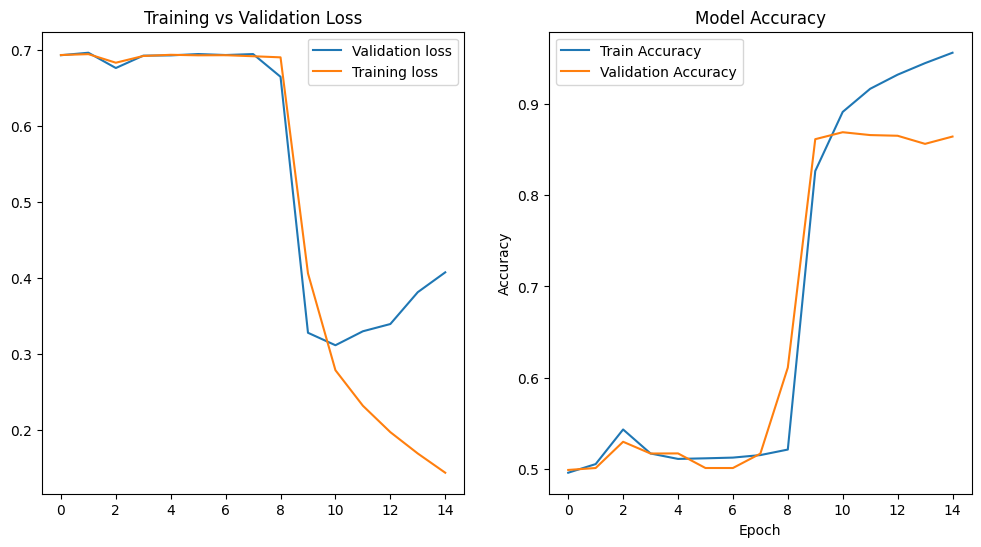

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(history.history['val_loss'], label="Validation loss")
plt.plot(history.history['loss'], label="Training loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:

nimages = min(10000, X_test.shape[0])
idx = np.random.choice(X_test.shape[0], nimages, replace=False)

# Saida sigmoide: probabilidade da classe positiva
y_prob = model.predict(X_test[idx], verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

y_true = y_test[idx]
if np.ndim(y_true) > 1:
    y_true = np.argmax(y_true, axis=1)

print('Test Accuracy = %.2f' % (100.0 * np.mean(y_pred == y_true)))

In [ ]:
import numpy as np
import pandas as pd

label_map = {0: "negative", 1: "positive"}

np.random.seed(42)
idx = np.random.choice(len(X_test), size=5, replace=False)

probs = model.predict(X_test[idx], verbose=0).flatten()
preds = (probs >= 0.5).astype(int)

resultados = pd.DataFrame({
    "review_teste": [X_test_text[i][:300] + "..." for i in idx],
    "pred_prob": probs,
    "pred_label": preds,
    "pred_sentiment": [label_map[p] for p in preds],
    "true_label": y_test[idx],
    "true_sentiment": [label_map[t] for t in y_test[idx]],
})

resultados

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg,rgb(66, 79, 30),rgb(142, 179, 33));
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">LSTM usando embed pre-treinado</span>
</div>

In [ ]:
model = Sequential([
    Input(shape=(max_word,)),
    Embedding(input_dim=max_features, output_dim=embed_size, trainable=True),
    LSTM(60),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 200, 300)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60)             │        86,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,587,633 (6.06 MB)

 Trainable params: 1,587,633 (6.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    verbose=2,
    validation_split=0.2
)

Epoch 1/15
250/250 - 39s - 155ms/step - accuracy: 0.5128 - loss: 0.6928 - val_accuracy: 0.5330 - val_loss: 0.6892
Epoch 2/15
250/250 - 39s - 155ms/step - accuracy: 0.5760 - loss: 0.6703 - val_accuracy: 0.7308 - val_loss: 0.5672
Epoch 3/15
250/250 - 38s - 153ms/step - accuracy: 0.8328 - loss: 0.4036 - val_accuracy: 0.8560 - val_loss: 0.3434
Epoch 4/15
250/250 - 39s - 157ms/step - accuracy: 0.8915 - loss: 0.2820 - val_accuracy: 0.8676 - val_loss: 0.3094
Epoch 5/15
250/250 - 37s - 149ms/step - accuracy: 0.9117 - loss: 0.2382 - val_accuracy: 0.8683 - val_loss: 0.3206
Epoch 6/15
250/250 - 38s - 154ms/step - accuracy: 0.9264 - loss: 0.2042 - val_accuracy: 0.8709 - val_loss: 0.3162
Epoch 7/15
250/250 - 40s - 159ms/step - accuracy: 0.9424 - loss: 0.1667 - val_accuracy: 0.8679 - val_loss: 0.3460
Epoch 8/15
250/250 - 39s - 158ms/step - accuracy: 0.9569 - loss: 0.1295 - val_accuracy: 0.8664 - val_loss: 0.3920
Epoch 9/15
250/250 - 46s - 184ms/step - accuracy: 0.9685 - loss: 0.0984 - val_accuracy: 

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(history.history['val_loss'], label="Validation loss")
plt.plot(history.history['loss'], label="Training loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg,rgb(66, 79, 30),rgb(142, 179, 33));
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">Acurácia com embeddings pre-treinados</span>
</div>

In [33]:

nimages = min(10000, X_test.shape[0])
idx = np.random.choice(X_test.shape[0], nimages, replace=False)

# Saida sigmoide: probabilidade da classe positiva
y_prob = model.predict(X_test[idx], verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

y_true = y_test[idx]
if np.ndim(y_true) > 1:
    y_true = np.argmax(y_true, axis=1)

print('Test Accuracy = %.2f' % (100.0 * np.mean(y_pred == y_true)))

Test Accuracy = 85.66


<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg,rgb(66, 79, 30),rgb(142, 179, 33));
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">5 exemplos do conjunto de teste com predição do modelo e rótulo verdadeiro com embeddings pre-treinados</span>
</div>

In [ ]:
import numpy as np
import pandas as pd

label_map = {0: "negative", 1: "positive"}

np.random.seed(42)
idx = np.random.choice(len(X_test), size=5, replace=False)

probs = model.predict(X_test[idx], verbose=0).flatten()
preds = (probs >= 0.5).astype(int)

resultados = pd.DataFrame({
    "review_teste": [X_test_text[i][:300] + "..." for i in idx],
    "pred_prob": probs,
    "pred_label": preds,
    "pred_sentiment": [label_map[p] for p in preds],
    "true_label": y_test[idx],
    "true_sentiment": [label_map[t] for t in y_test[idx]],
})

resultados

,review_teste,pred_prob,pred_label,pred_sentiment,true_label,true_sentiment
0,this is loosely based on the ideas of the orig...,0.000306,0,negative,0,negative
1,this movie was on british tv last night and is...,0.995968,1,positive,1,positive
2,what a dreadful movie the effects were poor es...,0.000867,0,negative,0,negative
3,i ll keep this short as i know i don t need to...,0.081638,0,negative,0,negative
4,i don t know what the rest of you guys watch s...,0.001373,0,negative,0,negative
